In [2]:
from __future__ import annotations

import sys

sys.path.append("PATH TO src folder")
sys.path.append("PATH TO DIRECTORY CONTAINING THIS NOTEBOOK")

In [3]:
%load_ext autoreload
%autoreload 2

# Setting Up and Importing the Necessary Packages/Libraries
##Package for reading in Bruker OPUS type files
import pathlib

import matplotlib.pyplot as plt

from prospecpy.baseline import (
    arpls_baseline_second_deriv_weights,  # 7.1
    raw_spline,  # arPLS 6.19
)

# Local Functions
from prospecpy.cut_range import cut_range_subtract_prospecpy_objects
from prospecpy.io import import_run_data
from prospecpy.peak_fit import gaussian_fit_prospecpy_objects, lorentzian_fit_prospecpy_objects
from prospecpy.second_deriv import second_deriv_prospecpy_objects

# Importing spectra data and water vapor data

# Creating Folders for Data and Plots

Within the data folder, create three more folders, water_vapor, output_plots, and one with a name describing this run or experiment.


In [4]:
# Paths to Local Data
path_to_water_vapor_data = pathlib.Path("../data/opus_files/water_vapor")
path_to_output_plots_ = pathlib.Path("../data/output_plots/")
# path_to_FILL_IN_data = pathlib.Path("../../data/opus_files/FILL_IN")
path_to_FILL_IN_data = pathlib.Path("../data/opus_files/pD6")

### Workflow Overview
The function called below `import_run_data`, creates a dict full of ProSpecPy objects, with empty attributes to be completed in the each of the following steps. For each of these steps, the function will write a corresponding plot labeled with the name of the sample to a folder describing the sample and step, within the `output_plots` directory specified above.


In [5]:
FILL_IN_raw_data = import_run_data(
    path_to_FILL_IN_data, input_type="raw spectra", output_folder="../output_plots/"
)

wv_data = import_run_data(path_to_water_vapor_data)

# Subtracting water vapor from raw spectra

Make sure to define the desired wave numbers for `range_start` and `range_end` which best fit your sample run.

In [6]:
# Initializing dict of post water vapor subtraction spectra
cut_range_subtract_prospecpy_objects(
    FILL_IN_raw_data, wv_data, range_start=2150, range_end=1850, showplots=False, verbose=True
)
# pD6_raw_data[].cut_subtracted_data

Plot saved to ../output_plots//pD6/167 Hyd1 pD6 cell 9 36 objective 20x20 m400.0013/cut_range_subtracted_spectra
Atmospheric fit parameters saved to ../output_plots//pD6/167 Hyd1 pD6 cell 9 36 objective 20x20 m400.0013/cut_atmfitparameters.csv
Cut subtracted data saved to ../output_plots//pD6/167 Hyd1 pD6 cell 9 36 objective 20x20 m400.0013/cut_subtracted_data.csv
Plot saved to ../output_plots//pD6/169 Hyd1 pD6 cell 9 36 objective 20x20 m425 titration.0023/cut_range_subtracted_spectra
Atmospheric fit parameters saved to ../output_plots//pD6/169 Hyd1 pD6 cell 9 36 objective 20x20 m425 titration.0023/cut_atmfitparameters.csv
Cut subtracted data saved to ../output_plots//pD6/169 Hyd1 pD6 cell 9 36 objective 20x20 m425 titration.0023/cut_subtracted_data.csv
Plot saved to ../output_plots//pD6/170 Hyd1 pD6 cell 9 36 objective 20x20 m450 titration.0008/cut_range_subtracted_spectra
Atmospheric fit parameters saved to ../output_plots//pD6/170 Hyd1 pD6 cell 9 36 objective 20x20 m450 titration.00

## Get the second derivatives

In [7]:
second_deriv_prospecpy_objects(FILL_IN_raw_data, show_plots=False, verbose=True)

Plot saved to ../output_plots//pD6/167 Hyd1 pD6 cell 9 36 objective 20x20 m400.0013/subtracted_spectra
Plot saved to ../output_plots//pD6/167 Hyd1 pD6 cell 9 36 objective 20x20 m400.0013/second_derivative_fig
Second derivative csv data saved to ../output_plots//pD6/167 Hyd1 pD6 cell 9 36 objective 20x20 m400.0013/second_derivative_data.csv
Plot saved to ../output_plots//pD6/169 Hyd1 pD6 cell 9 36 objective 20x20 m425 titration.0023/subtracted_spectra
Plot saved to ../output_plots//pD6/169 Hyd1 pD6 cell 9 36 objective 20x20 m425 titration.0023/second_derivative_fig
Second derivative csv data saved to ../output_plots//pD6/169 Hyd1 pD6 cell 9 36 objective 20x20 m425 titration.0023/second_derivative_data.csv
Plot saved to ../output_plots//pD6/170 Hyd1 pD6 cell 9 36 objective 20x20 m450 titration.0008/subtracted_spectra
Plot saved to ../output_plots//pD6/170 Hyd1 pD6 cell 9 36 objective 20x20 m450 titration.0008/second_derivative_fig
Second derivative csv data saved to ../output_plots//pD6/

## Selection of λ for arPLS

Representative spectra were used to determine an appropriate λ value for arPLS baseline estimation.

/workspaces/ProSpecPy/src/prospecpy/baseline.py:178: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:185: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


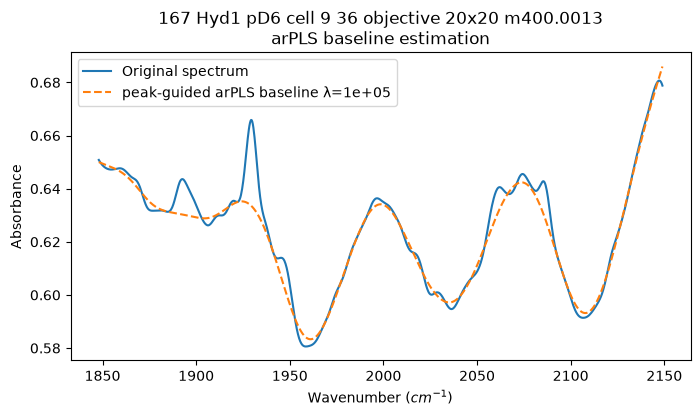

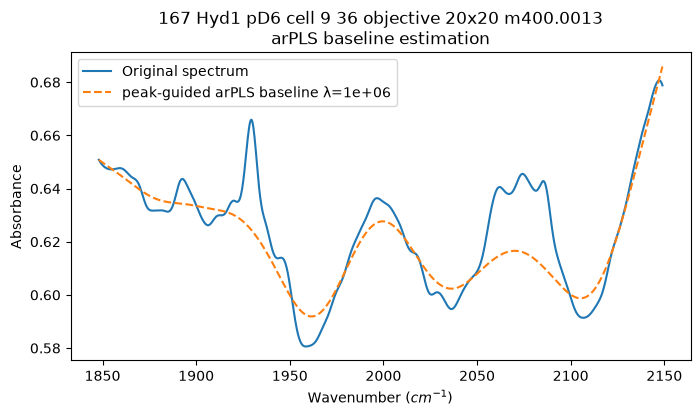

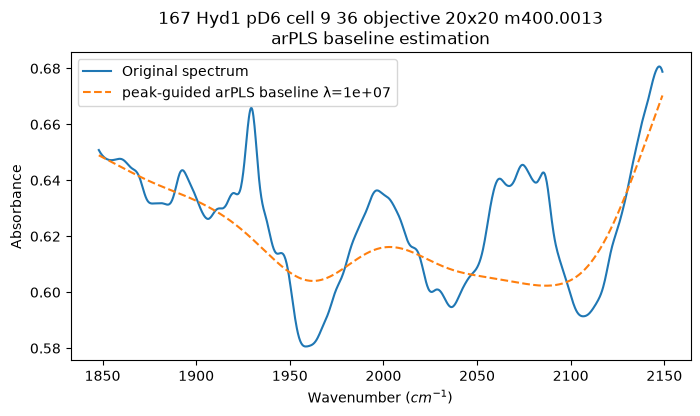

In [ ]:
test_object = FILL_IN_raw_data[0]

# peak_finder
test_object.peak_finder(0.35)

raw_x, raw_y = raw_spline(
    test_object.get_subtracted_spectra_wavenumber(), test_object.get_subtracted_spectra_absorbance()
)

peak_wavenumbers = test_object.second_deriv_peak_dict["peak_wavenumber"]

for lam in [1e5, 1e6, 1e7]:  # try different values, le5 is the best one
    baseline = arpls_baseline_second_deriv_weights(
        raw_y,
        raw_x,
        peak_wavenumbers,
        lam=lam,
    )

    plt.figure(figsize=(8, 4))
    plt.plot(raw_x, raw_y, label="Original spectrum")
    plt.plot(raw_x, baseline, "--", label=f"peak-guided arPLS baseline λ={lam:.0e}")

    plt.xlabel("Wavenumber ($cm^{-1}$)")
    plt.ylabel("Absorbance")
    plt.title(f"{test_object.sample_name}\narPLS baseline estimation")
    plt.legend()
    plt.show()

## Estimate and subtract baselines using the arPLS algorithm

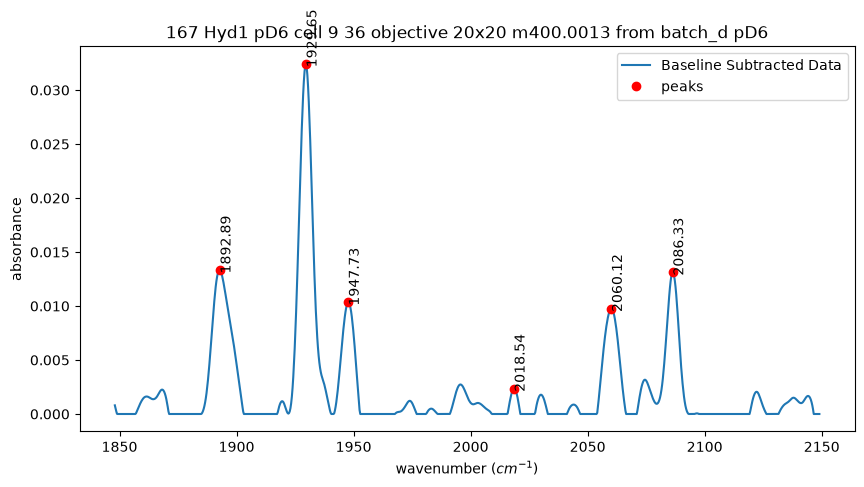

Plot saved to ../output_plots//pD6/167 Hyd1 pD6 cell 9 36 objective 20x20 m400.0013/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pD6/167 Hyd1 pD6 cell 9 36 objective 20x20 m400.0013/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pD6/167 Hyd1 pD6 cell 9 36 objective 20x20 m400.0013/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:178: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:185: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


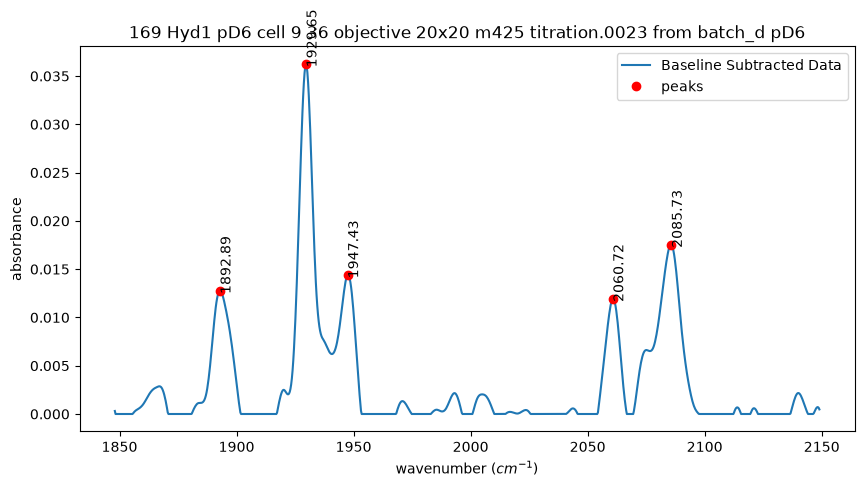

Plot saved to ../output_plots//pD6/169 Hyd1 pD6 cell 9 36 objective 20x20 m425 titration.0023/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pD6/169 Hyd1 pD6 cell 9 36 objective 20x20 m425 titration.0023/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pD6/169 Hyd1 pD6 cell 9 36 objective 20x20 m425 titration.0023/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:178: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:185: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


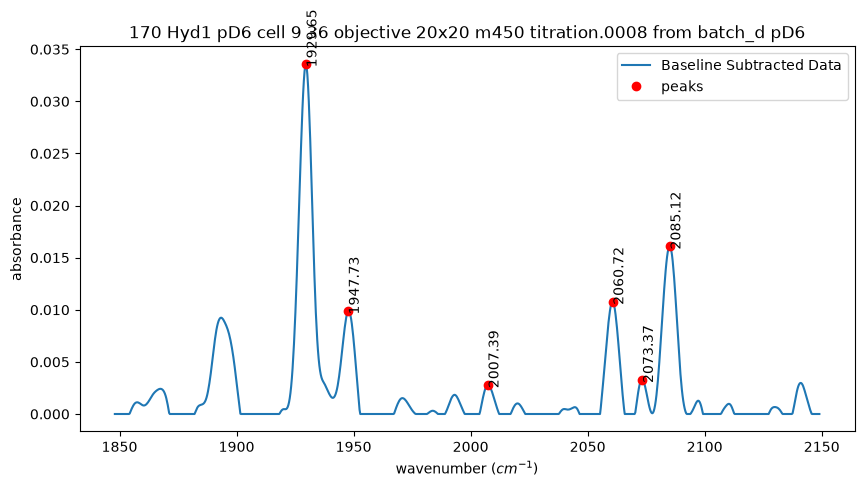

Plot saved to ../output_plots//pD6/170 Hyd1 pD6 cell 9 36 objective 20x20 m450 titration.0008/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pD6/170 Hyd1 pD6 cell 9 36 objective 20x20 m450 titration.0008/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pD6/170 Hyd1 pD6 cell 9 36 objective 20x20 m450 titration.0008/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:178: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:185: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


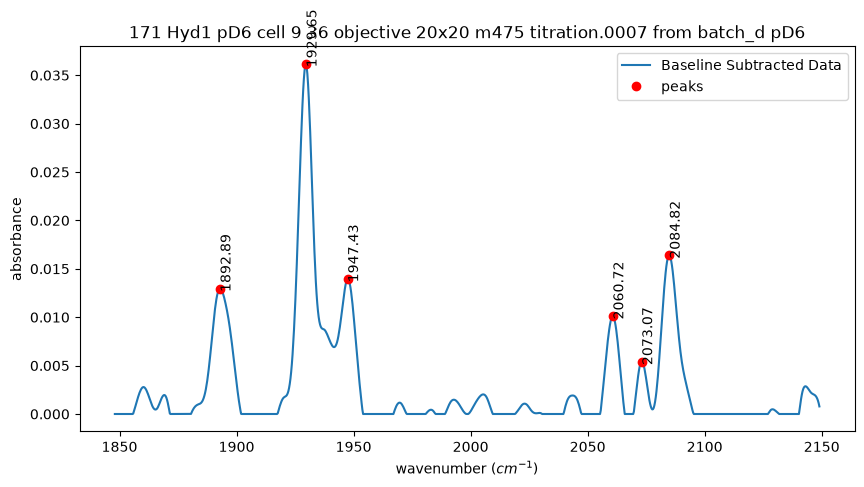

Plot saved to ../output_plots//pD6/171 Hyd1 pD6 cell 9 36 objective 20x20 m475 titration.0007/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pD6/171 Hyd1 pD6 cell 9 36 objective 20x20 m475 titration.0007/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pD6/171 Hyd1 pD6 cell 9 36 objective 20x20 m475 titration.0007/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:178: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:185: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


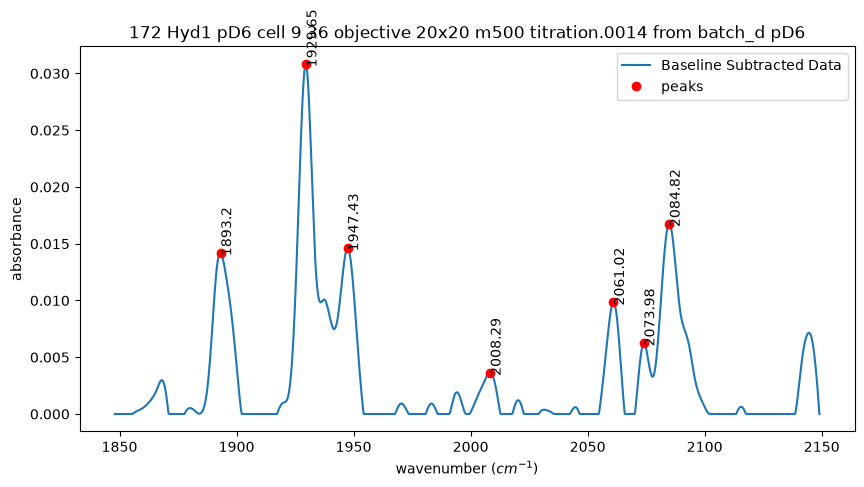

Plot saved to ../output_plots//pD6/172 Hyd1 pD6 cell 9 36 objective 20x20 m500 titration.0014/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pD6/172 Hyd1 pD6 cell 9 36 objective 20x20 m500 titration.0014/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pD6/172 Hyd1 pD6 cell 9 36 objective 20x20 m500 titration.0014/arpls_baseline_corrected_peak_info.csv


/workspaces/ProSpecPy/src/prospecpy/baseline.py:178: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:185: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


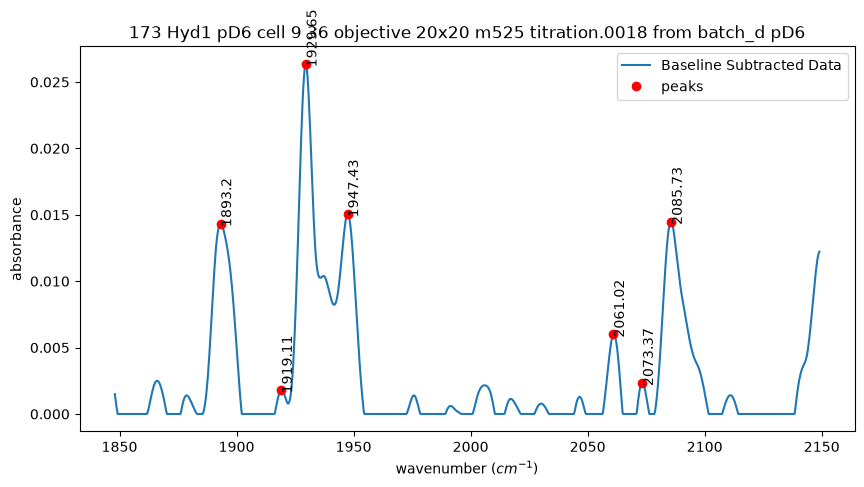

Plot saved to ../output_plots//pD6/173 Hyd1 pD6 cell 9 36 objective 20x20 m525 titration.0018/arpls_baseline_subtracted_spectra
arPLS baseline corrected csv data saved to ../output_plots//pD6/173 Hyd1 pD6 cell 9 36 objective 20x20 m525 titration.0018/arpls_baseline_corrected_data.csv
arPLS baseline corrected peak info saved to ../output_plots//pD6/173 Hyd1 pD6 cell 9 36 objective 20x20 m525 titration.0018/arpls_baseline_corrected_peak_info.csv


In [9]:
selected_lam = 1e5
peak_threshold = 0.35

for obj in FILL_IN_raw_data:
    obj.peak_finder(peak_threshold)

    obj.subtract_baseline_arpls(lam=selected_lam, save=True, showplot=True, verbose=True)

/workspaces/ProSpecPy/src/prospecpy/baseline.py:178: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  diff_matrix = sparse.diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
/workspaces/ProSpecPy/src/prospecpy/baseline.py:185: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  baseline = spsolve(weight_matrix + penalty_matrix, weights * y)


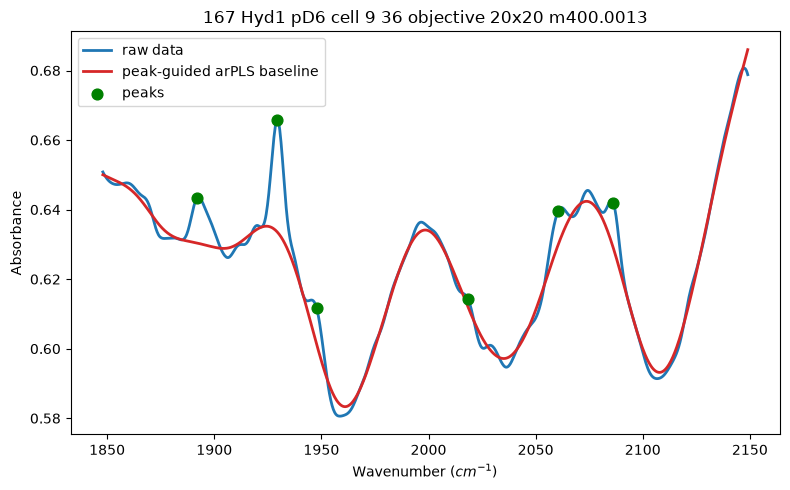

In [ ]:
test_object = FILL_IN_raw_data[0]

test_object.peak_finder(0.35)

raw_x, raw_y = raw_spline(
    test_object.get_subtracted_spectra_wavenumber(), test_object.get_subtracted_spectra_absorbance()
)

baseline = arpls_baseline_second_deriv_weights(
    raw_y,
    raw_x,
    test_object.second_deriv_peak_dict["peak_wavenumber"],
    lam=1e5,
)

peak_wv = test_object.second_deriv_peak_dict["peak_wavenumber"]

peak_abs = []
for wv in peak_wv:
    idx = abs(raw_x - wv).argmin()
    peak_abs.append(raw_y[idx])

plt.figure(figsize=(8, 5))

plt.plot(raw_x, raw_y, color="tab:blue", linewidth=2, label="raw data")
plt.plot(raw_x, baseline, color="tab:red", linewidth=2, label="peak-guided arPLS baseline")
plt.scatter(peak_wv, peak_abs, color="green", s=60, label="peaks", zorder=5)

plt.xlabel("Wavenumber ($cm^{-1}$)")
plt.ylabel("Absorbance")
plt.title(test_object.sample_name)
plt.legend()
plt.tight_layout()
plt.show()

# Fitting gaussian and lorentizian curves on the baseline corrected data

Please keep in mind, as of May 2nd, 2025, the following cells do not reliably fit functions to the baseline corrected curves. We have an open [issue](https://github.com/ProSpecPy/ProSpecPy/issues/12) to revert to a prior version of the software where users can enter their own guesses for the peaks, and fit the functions like so.

An error occurred: Optimal parameters not found: Number of calls to function has reached maxfev = 3800.
An error occurred: Optimal parameters not found: Number of calls to function has reached maxfev = 3200.


/workspaces/ProSpecPy/src/prospecpy/peak_fit.py:56: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(objective_function, x_wavenumber, y_absorbance, guess)


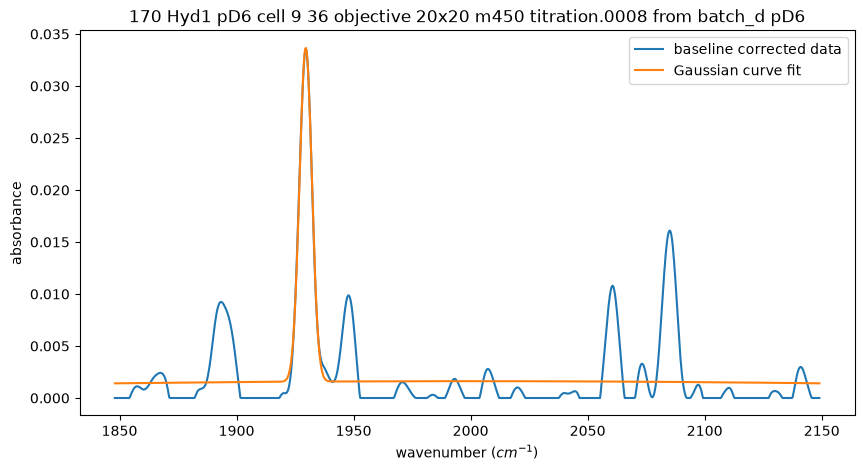

Plot saved to ../output_plots//pD6/170 Hyd1 pD6 cell 9 36 objective 20x20 m450 titration.0008/gaussian_fit_plot
Gaussian csv data saved to ../output_plots//pD6/170 Hyd1 pD6 cell 9 36 objective 20x20 m450 titration.0008/gaussian_fit_params.csv
An error occurred: Optimal parameters not found: Number of calls to function has reached maxfev = 3800.
An error occurred: Optimal parameters not found: Number of calls to function has reached maxfev = 4400.
An error occurred: Optimal parameters not found: Number of calls to function has reached maxfev = 4400.


In [11]:
gaussian_fit_prospecpy_objects(FILL_IN_raw_data, show_plots=True, save=True, verbose=True)

In [12]:
lorentzian_fit_prospecpy_objects(FILL_IN_raw_data, show_plots=True, save=True, verbose=True)

An error occurred: Optimal parameters not found: Number of calls to function has reached maxfev = 3800.
An error occurred: Optimal parameters not found: Number of calls to function has reached maxfev = 3200.
An error occurred: Optimal parameters not found: Number of calls to function has reached maxfev = 3800.
An error occurred: Optimal parameters not found: Number of calls to function has reached maxfev = 3800.
An error occurred: Optimal parameters not found: Number of calls to function has reached maxfev = 4400.
An error occurred: Optimal parameters not found: Number of calls to function has reached maxfev = 4400.
